# Linear Combination of Atomic Orbitals (LCAO) Method

Linear combination of atomic orbitals (LCAO) approximation assumes that the molecular orbitals can be expressed as a linear combination of atomic orbitals. For example, 

$$|\psi\rangle  = \sum_j \sum_i c_{ij} | i \rangle_j$$

where $| i \rangle_j$ is the complete basis of $i$-th atomic orbital with $j$-th state, and $c_{ij}$ is the corresponding coefficient.

The Hamiltonian of the system can be expressed as:

$$H = T + \sum_i V_i$$

where each element is 

$$
\begin{aligned}
\langle i' |_{j'} H | i \rangle _j =& \langle i' |_{j'} E_i + \hat{V}_j | i \rangle _j\\
=& \int_{-\infty}^{\infty}\psi_{i'}^*(x \pm nb) \left[ E_i + \hat{V}(x) \right] \psi_i(x) dx 
\end{aligned}
$$

where $\hat{V}(x) = \sum_{k \neq j} \hat{V}_k(x)$ is the potential of all other wells, and
$n = j-j'$ is number of wells between the two states.


Text(0, 0.5, 'V(x)')

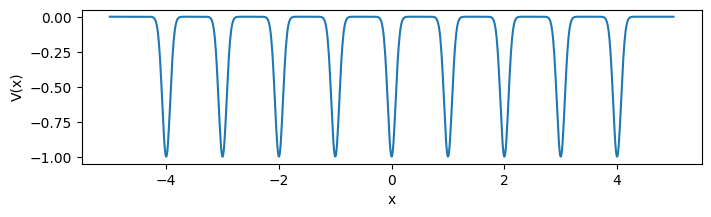

In [8]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-5, 5, 1000)
y = np.sum([-np.exp(-((x - i)**2) / 0.1**2) for i in range(-4, 5)], axis=0)
plt.figure(figsize=(8, 2))
plt.plot(x, y)
plt.xlabel('x')
plt.ylabel('V(x)')

To solve for single wall potential, we can discretize the Hamiltonian and solve for the eigenvalues and eigenvectors. The time-independent Schrödinger equation is given by:

$$\left(-\frac{\hbar^2}{2m}\frac{d^2}{dx^2} +V(x) \right)\psi(x) = E \psi(x)$$

We can discretize using the expression that

$$\frac{d^2 \psi}{dx^2}(x_i) \approx \frac{-2\psi_i + \psi_{i-1}+\psi_{i+1}}{\Delta x^2}$$

Schrodinger equation can be rewritten as:

$$\frac{2\psi_i - \psi_{i-1}-\psi_{i+1}}{\Delta x^2} + V_i \psi_i  = E \psi_i$$

With assumption of $\psi_0 = \psi_{N+1} = 0$, we can express the Hamiltonian in matrix form as:

$$ \begin{bmatrix}\frac{2}{\Delta x^2}+V_1 & -\frac{1}{\Delta x^2} &   0 & 0...\\ -\frac{1}{\Delta x^2} & \frac{2}{\Delta x^2}+V_2 & -\frac{1}{\Delta x^2} & 0... \\ ...& ... & ... & -\frac{1}{ \Delta x^2}\\...0 & 0 & -\frac{1}{\Delta x^2} & \frac{2}{\Delta x^2}+V_{N-1} \\ \end{bmatrix} \begin{bmatrix} \psi_1 \\ \psi_2 \\ ... \\ \psi_{N-1} \end{bmatrix} = E \begin{bmatrix} \psi_1 \\ \psi_2 \\ ... \\ \psi_{N-1} \end{bmatrix} $$



In [19]:
from scipy.linalg import eigh_tridiagonal

def eigen_single_wall(x, V, V0):
    N = len(x)
    dx = np.diff(x)[0]
    main_diag = 2*np.ones(N)/dx**2 + V(x,V0)
    off_diag =  -np.ones(N-1)/dx**2
    Es, psis = eigh_tridiagonal(main_diag, off_diag, select='v', select_range=(-V0,0))
    psis = psis/np.sqrt((np.abs(psis)**2).sum(axis=0) * dx)
    return Es, psis.T

## Example: Finite Square Well Potential (single bound state)

- $V_0 = 1eV$
- well width $2a = 0.35 \text{ nm}$
- well spacing $b = 3 \cdot 2a \text{ nm}$

Text(0, 0.5, 'V(x)')

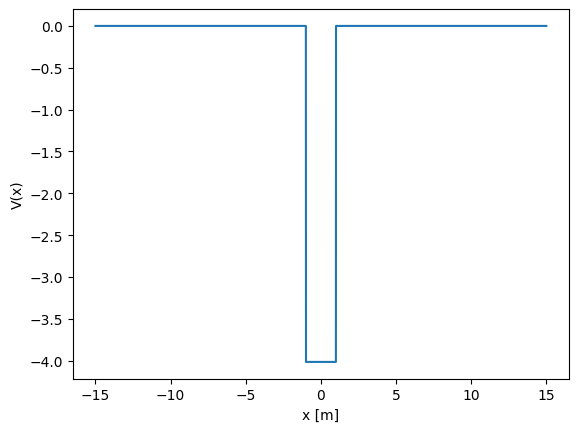

In [79]:
V0 = 5 # eV
a = 0.35e-9/2 # m
b = 3 * 2 # m

hbar = 6.582119569e-16 # eV*s
m = 0.511e6 / (3e8)**2 # eV s^2 / m^2
f = hbar**2 / (2 * m * a**2) # factor for energy unit conversion to unitless

V0 = V0 / f

x = np.linspace(-15, 15, 10000)
V = lambda x, V0: -V0*np.array((x>=-1)*(x<=1), dtype=float)
plt.plot(x, V(x, V0))
plt.xlabel('x [m]')
plt.ylabel('V(x)')

[[<matplotlib.lines.Line2D at 0x11a5682d0>],

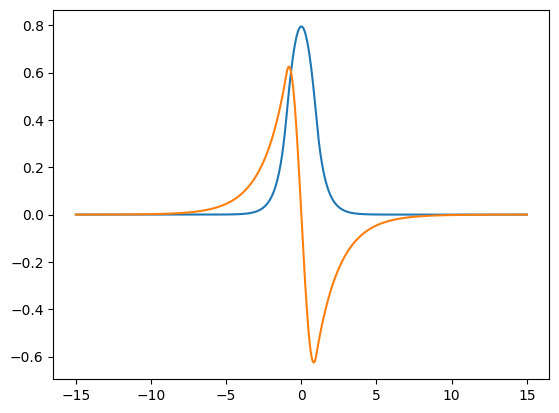

In [80]:
es, psis = eigen_single_wall(x, V, V0)
[plt.plot(x, psi) for psi in psis]

For this potential well, there are two bound states for each well.

interpolate this eigenvector to calculate integral later

In [82]:
from scipy.interpolate import interp1d
psis_f = [interp1d(x, psi, bounds_error = False, fill_value = (0,0)) for psi in psis]

Lets now consider $\hat{V}(x) = \sum_{k \neq j} \hat{V}_k(x)$, which is the potential of all other wells.

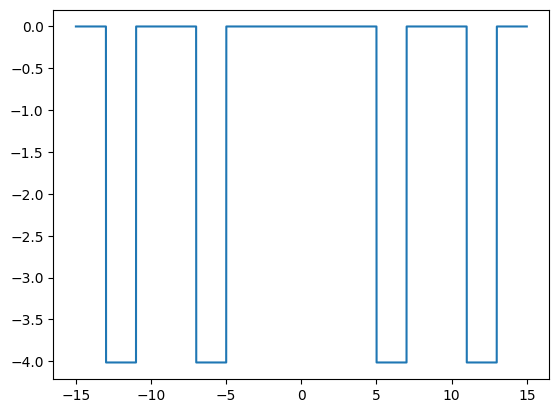

In [83]:
Vp_f = lambda x, b, V0: V((x+b/2)%b-b/2, V0) - V(x, V0)
plt.plot(x, Vp_f(x, b, V0))

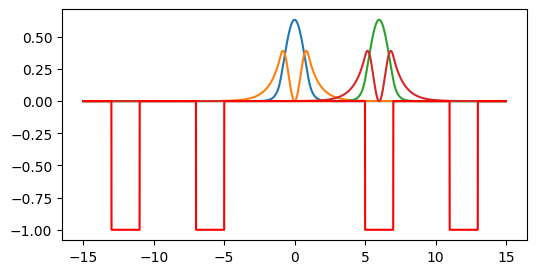

In [89]:
plt.figure(figsize=(6,3))
for n in range(2):
    for i in range(2):
        plt.plot(x, psis_f[i](x - n*b)**2, label=f'psi_{i}^2')
plt.plot(x, Vp_f(x,b,V0)/V0, color='red')
plt.show()

In [90]:
from scipy.integrate import quad
def compute_integral(psis_f, Es, i1, i2, b, V0, n):
    return quad(lambda x: psis_f[i1](x)*psis_f[i2](x-n*b)*(Es[i1]+Vp_f(x, b, V0)),
                -20, 20, points=[n*b for n in range(-6,6)], limit=1000)[0] 

Next, lets consider Hamiltonan matrix

In [91]:
N_wells = 20
N_states = len(es)
H = np.zeros((N_wells*N_states,N_wells*N_states))

In [93]:
psis_tot = N_wells*psis_f
Es_tot = N_wells*list(es)
for i1 in range(H.shape[0]):
    for i2 in range(i1, H.shape[0]):
        well1_idx = i1//N_states
        well2_idx = i2//N_states
        H[i1,i2] = compute_integral(psis_tot,Es_tot,i1,i2,b=b,V0=V0,n=well2_idx-well1_idx)
H += H.T # make it symmetric. This will double the diagonal term.
# fix the diagonal term
main_diag = np.array(list(es)*N_wells)
H[np.diag_indices(H.shape[0])] = main_diag

/var/folders/5j/7wvtt6b90dl7r_nz2w93dwy00000gn/T/ipykernel_25001/1770882746.py:3: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  return quad(lambda x: psis_f[i1](x)*psis_f[i2](x-n*b)*(Es[i1]+Vp_f(x, b, V0)),


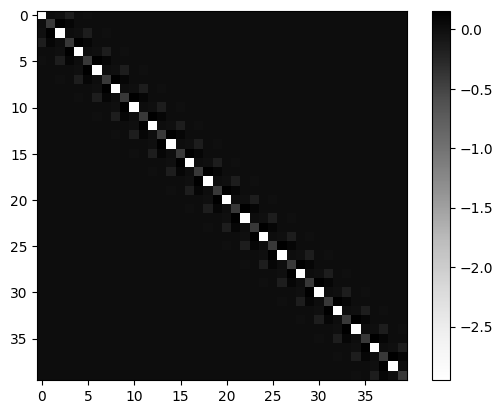

In [94]:
plt.imshow(H, cmap='Greys')
plt.colorbar()

Text(0, 0.5, 'Energy (eV)')

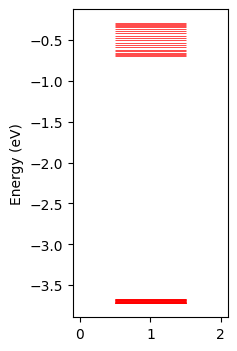

In [95]:
eigenenergies, eigenvectors = np.linalg.eigh(H)
plt.figure(figsize=(2,4))
plt.eventplot(f*eigenenergies, orientation='vertical', colors='r', linewidths=0.5)
plt.ylabel('Energy (eV)')

## Reference
- [Luke Polson's Tutorial](https://www.youtube.com/watch?v=YzuaiD2e5oI&list=PLkdGijFCNuVnMsuC4uFncWusSA9aUzzIp&index=31)